In [1]:

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)


2026-03-30 18:13:45.660404: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-30 18:13:46.534276: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-30 18:13:48.288032: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:

PROJECT_ROOT = Path("..").resolve()
DATA_MASTER_CSV = PROJECT_ROOT / "data" / "data_master.csv"
MODEL_OUT = Path("angular_predictor.keras")
PREPROCESS_OUT = Path("angular_predictor_preprocessing.json")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30
VAL_SPLIT = 0.1
TEST_SPLIT = 0.1
AUTOTUNE = tf.data.AUTOTUNE

assert DATA_MASTER_CSV.exists(), DATA_MASTER_CSV


In [3]:

def normalize_rows(v: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    n = np.linalg.norm(v, axis=1, keepdims=True)
    return v / np.clip(n, eps, None)


def add_camera_space_targets(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    cam_pos = out[["cam_pos_x", "cam_pos_y", "cam_pos_z"]].to_numpy(dtype=np.float32)
    cam_right = normalize_rows(out[["cam_right_x", "cam_right_y", "cam_right_z"]].to_numpy(dtype=np.float32))
    cam_up = normalize_rows(out[["cam_up_x", "cam_up_y", "cam_up_z"]].to_numpy(dtype=np.float32))
    cam_forward = normalize_rows(out[["cam_forward_x", "cam_forward_y", "cam_forward_z"]].to_numpy(dtype=np.float32))
    cam_back = -cam_forward

    light_pos = out[["light0_pos_x", "light0_pos_y", "light0_pos_z"]].to_numpy(dtype=np.float32)
    light_dir = normalize_rows(out[["light0_dir_x", "light0_dir_y", "light0_dir_z"]].to_numpy(dtype=np.float32))
    rel = light_pos - cam_pos

    out["light0_pos_cam_x"] = np.einsum("ij,ij->i", rel, cam_right)
    out["light0_pos_cam_y"] = np.einsum("ij,ij->i", rel, cam_up)
    out["light0_pos_cam_z"] = np.einsum("ij,ij->i", rel, cam_back)

    out["light0_dir_cam_x"] = np.einsum("ij,ij->i", light_dir, cam_right)
    out["light0_dir_cam_y"] = np.einsum("ij,ij->i", light_dir, cam_up)
    out["light0_dir_cam_z"] = np.einsum("ij,ij->i", light_dir, cam_back)

    return out


def load_image(path: str) -> np.ndarray:
    with Image.open(path) as img:
        img = img.convert("RGB").resize(IMG_SIZE, Image.BILINEAR)
        return np.asarray(img, dtype=np.float32) / 255.0


In [4]:
df = pd.read_csv(DATA_MASTER_CSV, low_memory=False)

required_cols = [
    "num_active_lights",
    "light0_type",
    "cam_pos_x", "cam_pos_y", "cam_pos_z",
    "cam_right_x", "cam_right_y", "cam_right_z",
    "cam_up_x", "cam_up_y", "cam_up_z",
    "cam_forward_x", "cam_forward_y", "cam_forward_z",
    "light0_energy",
    "light0_color_r", "light0_color_g", "light0_color_b",
    "light0_spot_cone_deg",
    "light0_pos_x", "light0_pos_y", "light0_pos_z",
    "light0_dir_x", "light0_dir_y", "light0_dir_z",
]


def resolve_existing_image(row: pd.Series) -> str | None:
    for key in ["resolved_image_relpath", "image_relpath"]:
        raw = row.get(key)
        if pd.isna(raw):
            continue

        p = Path(str(raw))
        candidates = []
        if p.is_absolute():
            candidates.append(p)
        else:
            candidates.extend([
                PROJECT_ROOT / p,
                PROJECT_ROOT / "data" / p,
                PROJECT_ROOT / "data" / "render-lighting" / p,
                PROJECT_ROOT / "data" / "inverse_rendering_dataset" / p,
                PROJECT_ROOT / "data" / "inverse_rendering_dataset" / "images" / p,
                PROJECT_ROOT / "data" / "spotlight-sphere-data" / p,
                PROJECT_ROOT / "data" / "two_object" / p,
            ])

        for candidate in candidates:
            if candidate.exists():
                return str(candidate)

    return None


usable = df.copy()
usable["image_path"] = usable.apply(resolve_existing_image, axis=1)
usable = usable[usable["image_path"].notna()]
usable = usable[usable["num_active_lights"].fillna(0).astype(int) == 1]
for col in required_cols:
    usable = usable[usable[col].notna()]

usable = usable.reset_index(drop=True)
usable = add_camera_space_targets(usable)
usable["light_type_label"] = usable["light0_type"].astype(str).str.upper()

print("Usable rows:", len(usable))
print(usable.groupby(["dataset_source", "light_type_label"]).size())
print("Dataset counts:")
print(usable["dataset_source"].value_counts())


Usable rows: 8127
dataset_source             light_type_label
inverse_rendering_dataset  SPOT                1473
render-lighting            SPOT                5304
two_object                 SPOT                1350
dtype: int64
Dataset counts:
dataset_source
render-lighting              5304
inverse_rendering_dataset    1473
two_object                   1350
Name: count, dtype: int64


In [5]:

feature_cols = [
    "num_active_lights",
    "cam_pos_x", "cam_pos_y", "cam_pos_z",
    "light0_energy",
    "light0_color_r", "light0_color_g", "light0_color_b",
    "light0_spot_cone_deg",
]
cat_cols = ["light_type_label"]
target_cols = [
    "light0_pos_cam_x", "light0_pos_cam_y", "light0_pos_cam_z",
    "light0_dir_cam_x", "light0_dir_cam_y", "light0_dir_cam_z",
]

features_df = usable[feature_cols + cat_cols].copy()
features_df = pd.get_dummies(features_df, columns=cat_cols, drop_first=False)
feature_names = features_df.columns.tolist()

x_img_paths = usable["image_path"].to_numpy()
x_tab_raw = features_df.to_numpy(dtype=np.float32)
y_raw = usable[target_cols].to_numpy(dtype=np.float32)

indices = np.arange(len(usable))
train_idx, temp_idx = train_test_split(indices, test_size=VAL_SPLIT + TEST_SPLIT, random_state=42, shuffle=True)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT),
    random_state=42,
    shuffle=True,
)

x_tab_mean = x_tab_raw[train_idx].mean(axis=0, keepdims=True)
x_tab_std = x_tab_raw[train_idx].std(axis=0, keepdims=True)
x_tab_std[x_tab_std < 1e-8] = 1.0

y_mean = y_raw[train_idx].mean(axis=0, keepdims=True)
y_std = y_raw[train_idx].std(axis=0, keepdims=True)
y_std[y_std < 1e-8] = 1.0

x_tab = (x_tab_raw - x_tab_mean) / x_tab_std
y = (y_raw - y_mean) / y_std

print("x_tab shape:", x_tab.shape)
print("y shape:", y.shape)
print("train/val/test:", len(train_idx), len(val_idx), len(test_idx))
print("feature_names:", feature_names)


x_tab shape: (8127, 10)
y shape: (8127, 6)
train/val/test: 6501 813 813
feature_names: ['num_active_lights', 'cam_pos_x', 'cam_pos_y', 'cam_pos_z', 'light0_energy', 'light0_color_r', 'light0_color_g', 'light0_color_b', 'light0_spot_cone_deg', 'light_type_label_SPOT']


In [6]:
def build_dataset(idxs, training=False):
    image_paths = x_img_paths[idxs]
    x_tab_split = x_tab[idxs].astype(np.float32)
    y_split = y[idxs].astype(np.float32)

    def gen():
        for path, tab, target in zip(image_paths, x_tab_split, y_split):
            yield (load_image(path), tab), target

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            (
                tf.TensorSpec(shape=(*IMG_SIZE, 3), dtype=tf.float32),
                tf.TensorSpec(shape=(x_tab.shape[1],), dtype=tf.float32),
            ),
            tf.TensorSpec(shape=(y.shape[1],), dtype=tf.float32),
        ),
    )

    if training:
        ds = ds.shuffle(len(idxs), reshuffle_each_iteration=True)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_steps = int(np.ceil(len(train_idx) / BATCH_SIZE))
val_steps = int(np.ceil(len(val_idx) / BATCH_SIZE))
test_steps = int(np.ceil(len(test_idx) / BATCH_SIZE))

train_ds = build_dataset(train_idx, training=True).repeat()
val_ds = build_dataset(val_idx).repeat()
test_ds = build_dataset(test_idx)

print("steps per epoch:", train_steps)
print("validation steps:", val_steps)
print("test steps:", test_steps)


steps per epoch: 204
validation steps: 26
test steps: 26


E0000 00:00:1774912432.707406  274238 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774912432.722590  274238 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:

img_input = keras.Input(shape=(*IMG_SIZE, 3), name="image")
x = layers.Conv2D(32, 3, activation="relu", padding="same")(img_input)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.25)(x)

tab_input = keras.Input(shape=(x_tab.shape[1],), name="tabular")
t = layers.Dense(64, activation="relu")(tab_input)
t = layers.Dense(32, activation="relu")(t)

merged = layers.Concatenate()([x, t])
merged = layers.Dense(128, activation="relu")(merged)
merged = layers.Dropout(0.25)(merged)
merged = layers.Dense(64, activation="relu")(merged)
out = layers.Dense(len(target_cols), name="camera_space_light")(merged)

model = keras.Model(inputs=[img_input, tab_input], outputs=out, name="angular_predictor")
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
model.summary()


Model: "angular_predictor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ conv2d_3[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular             │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        704 │ tabular[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     20,608 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ camera_space_light  │ (None, 6)         │        390 │ dense_4[0][0]     │
│ (Dense)             │                   │            │                 

 Total params: 453,350 (1.73 MB)

 Trainable params: 453,350 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
)


Epoch 1/30


2026-03-30 18:14:04.669158: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1878 of 6501
2026-03-30 18:14:24.661786: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 5779 of 6501
2026-03-30 18:14:28.300253: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


204/204 ━━━━━━━━━━━━━━━━━━━━ 207s 839ms/step - loss: 0.5254 - mae: 0.5001 - val_loss: 0.3634 - val_mae: 0.3309 - learning_rate: 0.0010
Epoch 2/30


2026-03-30 18:17:21.460322: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1191 of 6501
2026-03-30 18:17:31.461321: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 3138 of 6501
2026-03-30 18:17:41.461704: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 5094 of 6501
2026-03-30 18:17:48.540655: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


204/204 ━━━━━━━━━━━━━━━━━━━━ 197s 823ms/step - loss: 0.3787 - mae: 0.3722 - val_loss: 0.2996 - val_mae: 0.2873 - learning_rate: 0.0010
Epoch 3/30


...

145/204 ━━━━━━━━━━━━━━━━━━━━ 49s 834ms/step - loss: 0.0665 - mae: 0.1274

2026-03-30 19:43:33.553521: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 5786 of 6501


154/204 ━━━━━━━━━━━━━━━━━━━━ 41s 835ms/step - loss: 0.0665 - mae: 0.1273

2026-03-30 19:43:41.097637: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


204/204 ━━━━━━━━━━━━━━━━━━━━ 175s 860ms/step - loss: 0.0703 - mae: 0.1298 - val_loss: 0.0751 - val_mae: 0.1060 - learning_rate: 2.5000e-04


In [9]:

test_metrics = model.evaluate(test_ds, verbose=0)
print(dict(zip(model.metrics_names, test_metrics)))


{'loss': 0.07882138341665268, 'compile_metrics': 0.11315689980983734}


2026-03-30 19:44:39.486614: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/home/kaclark219/anaconda3/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [10]:
model.save(MODEL_OUT)

preprocess_payload = {
    "image_size": list(IMG_SIZE),
    "feature_names": feature_names,
    "feature_means": x_tab_mean.squeeze(0).tolist(),
    "feature_stds": x_tab_std.squeeze(0).tolist(),
    "target_names": target_cols,
    "target_means": y_mean.squeeze(0).tolist(),
    "target_stds": y_std.squeeze(0).tolist(),
    "train_size": int(len(train_idx)),
    "val_size": int(len(val_idx)),
    "test_size": int(len(test_idx)),
    "data_rows": int(len(usable)),
    "filters": {
        "resolved_on_disk": True,
        "num_active_lights": 1,
        "required_columns": required_cols,
    },
}

with open(PREPROCESS_OUT, "w", encoding="utf-8") as f:
    json.dump(preprocess_payload, f, indent=2)

print("Saved model:", MODEL_OUT.resolve())
print("Saved preprocessing:", PREPROCESS_OUT.resolve())


Saved model: /home/kaclark219/Documents/Programming/xrlive/inverse-rendering/models/angular_predictor.keras
Saved preprocessing: /home/kaclark219/Documents/Programming/xrlive/inverse-rendering/models/angular_predictor_preprocessing.json


In [11]:

preds_z = model.predict(test_ds, verbose=0)
y_test_z = np.concatenate([batch_y for _, batch_y in test_ds], axis=0)

preds = preds_z * y_std + y_mean
y_true = y_test_z * y_std + y_mean

sample_count = min(5, len(preds))
for i in range(sample_count):
    print(f"Sample {i}")
    print("  true pos:", np.round(y_true[i, :3], 3).tolist())
    print("  pred pos:", np.round(preds[i, :3], 3).tolist())
    print("  true dir:", np.round(y_true[i, 3:], 3).tolist())
    print("  pred dir:", np.round(preds[i, 3:], 3).tolist())


2026-03-30 19:44:46.522479: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Sample 0
  true pos: [3.752000093460083, 1.3830000162124634, -11.592000007629395]
  pred pos: [3.61299991607666, 1.6239999532699585, -11.104999542236328]
  true dir: [-0.9399999976158142, -0.3310000002384186, 0.08399999886751175]
  pred dir: [-0.8309999704360962, -0.5210000276565552, -0.02500000037252903]
Sample 1
  true pos: [-0.004000000189989805, 0.5189999938011169, 0.1340000033378601]
  pred pos: [0.023000000044703484, 0.5699999928474426, 0.1289999932050705]
  true dir: [0.0020000000949949026, -0.11699999868869781, -0.9929999709129333]
  pred dir: [0.0010000000474974513, -0.13199999928474426, -0.9850000143051147]
Sample 2
  true pos: [4.133999824523926, -1.0789999961853027, -10.211000442504883]
  pred pos: [2.315999984741211, -1.1990000009536743, -9.069999694824219]
  true dir: [-0.8899999856948853, -0.05000000074505806, -0.453000009059906]
  pred dir: [-0.5389999747276306, 0.2840000092983246, -0.5699999928474426]
Sample 3
  true pos: [2.114000082015991, 2.069999933242798, -1.41700

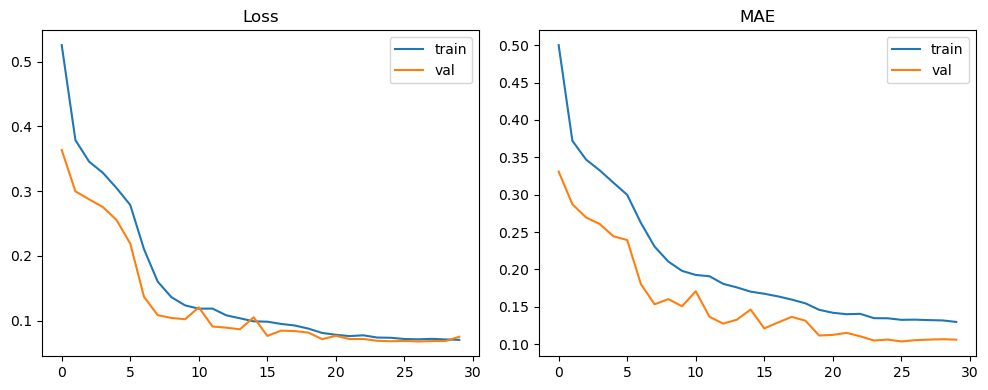

In [12]:

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="train")
plt.plot(history.history["val_mae"], label="val")
plt.title("MAE")
plt.legend()
plt.tight_layout()
plt.show()
